# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

### Prepared by: [Alexis Chacon]

## 0. Instalación y librerías

Instalamos las librerías necesarias: `transformers` (modelo CLIP de HuggingFace), `torch`, `pillow` para imágenes, `scikit-learn` para PCA/t-SNE y `matplotlib` para graficar.


In [1]:
!pip install -q transformers torch torchvision pillow scikit-learn matplotlib umap-learn

In [12]:
!pip install datasets

  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.19-py311-none-any.whl.metadata (7.5 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohttp-3.14.1-cp311-cp311-win_amd64.whl.metadata (8.5 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp311-cp311-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.2-cp311-cp311-win_amd64.whl.metadata (97 kB)
Using cached datasets-5.0.0-py3-none-any.whl (555 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
Using cached multiprocess-0.70.19-py311-none-any.whl (144 kB)
Using cached aiohttp

## 1. Obtener embeddings de imágenes y textos con CLIP

Cargamos el modelo preentrenado `openai/clip-vit-base-patch32` junto con su procesador. CLIP tiene dos encoders (uno de imagen y uno de texto) que fueron entrenados de forma contrastiva para que representaciones de imágenes y textos relacionados queden cerca en el mismo espacio vectorial.

In [2]:
import torch
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", device)

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

model.eval()
print("Modelo CLIP cargado correctamente.")

e:\Data\Universidad\6-7 Semestre\Recuperacion De La Informacion 26a\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando dispositivo: cpu


e:\Data\Universidad\6-7 Semestre\Recuperacion De La Informacion 26a\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AdminPC\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24514.05

Modelo CLIP cargado correctamente.


### 1.1 Preparar el dataset de imágenes y textos

Para no depender de descargar imágenes externas, generamos un pequeño set de **imágenes sintéticas** con formas y colores simples usando `PIL`. Cada imagen tiene una descripción textual asociada.

Se cargaron 4 imágenes de ejemplo.
  img_0: ' smartphone, macbook, mac
  img_1: ' writing, watch, work
  img_2: ' macbook, writing, screen
  img_3: ' iphone, macbook, mac


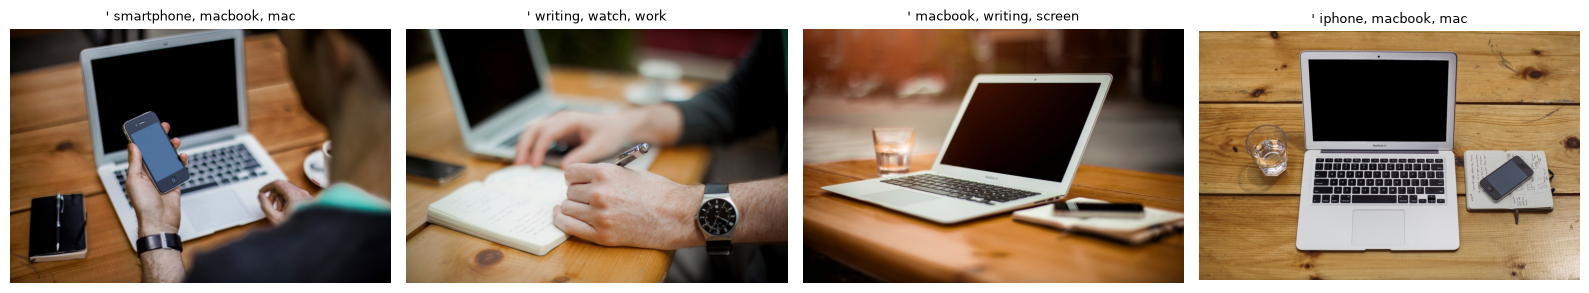

In [39]:
from datasets import load_dataset

# Cargamos el dataset en modo streaming (no descarga todo, solo lo que iteramos)
ds = load_dataset("KoalaAI/StockImages-CC0", split="train", streaming=True)

N_EXAMPLES = 4
examples = list(ds.take(N_EXAMPLES))

images = []
text_prompts = []
for ex in examples:
    img = ex["image"].convert("RGB")
    tags = ex["tags"]  # string de tags separados por coma, ej: "beach, ocean, sunset"
    # Limpiamos: quitamos espacios y descartamos tags vacíos antes de tomar los primeros 3
    tag_list = [t.strip() for t in tags.split(",") if t.strip()]
    caption = ", ".join(tag_list[:3]) if tag_list else "sin etiquetas"
    images.append(img)
    text_prompts.append(caption)

print(f"Se cargaron {len(images)} imágenes de ejemplo.")
for i, cap in enumerate(text_prompts):
    print(f"  img_{i}: {cap}")

# Visualizamos las imágenes cargadas
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
if len(images) == 1:
    axes = [axes]
for ax, img, cap in zip(axes, images, text_prompts):
    ax.imshow(img)
    ax.set_title(cap, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 1.2 Calcular los embeddings con CLIP

Usamos `processor` para convertir imágenes y textos al formato que espera el modelo, y luego `model.get_image_features` / `model.get_text_features` para obtener los vectores de embedding.

In [40]:
with torch.no_grad():
    # Embeddings de imagen
    image_inputs = processor(images=images, return_tensors="pt").to(device)
    image_out = model.get_image_features(**image_inputs)

    # Embeddings de texto
    text_inputs = processor(text=text_prompts, return_tensors="pt", padding=True).to(device)
    text_out = model.get_text_features(**text_inputs)

# --- Blindaje: algunas versiones de `transformers` devuelven el tensor directo,
# otras devuelven un objeto de salida con el tensor dentro de un atributo. ---
def extract_tensor(output):
    if torch.is_tensor(output):
        return output
    for attr in ("image_embeds", "text_embeds", "pooler_output", "last_hidden_state"):
        if hasattr(output, attr):
            val = getattr(output, attr)
            if torch.is_tensor(val):
                return val
    raise TypeError(f"No se pudo extraer un tensor de: {type(output)}")

image_embeds = extract_tensor(image_out)
text_embeds = extract_tensor(text_out)

# Normalizamos los vectores (CLIP se entrena comparando vectores normalizados con cosine similarity)
image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

image_embeds_np = image_embeds.cpu().numpy()
text_embeds_np = text_embeds.cpu().numpy()

print("Forma embeddings de imagen:", image_embeds_np.shape)
print("Forma embeddings de texto :", text_embeds_np.shape)

Forma embeddings de imagen: (4, 512)
Forma embeddings de texto : (4, 512)


## 2. Mostrar que ambos viven en el mismo espacio

Un requisito clave de un modelo multimodal como CLIP es que los embeddings de imagen y texto tengan **la misma dimensionalidad** y sean **directamente comparables** (por ejemplo con producto punto o cosine similarity), sin necesidad de ninguna transformación adicional.

In [41]:
print(f"Dimensión de embeddings de imagen: {image_embeds_np.shape[1]}")
print(f"Dimensión de embeddings de texto : {text_embeds_np.shape[1]}")
print(f"¿Misma dimensión? {image_embeds_np.shape[1] == text_embeds_np.shape[1]}")

print("\nNorma (deben ser ~1.0 tras la normalización):")
print("Imagen:", np.linalg.norm(image_embeds_np, axis=1) if False else (image_embeds_np**2).sum(axis=1)**0.5)
print("Texto :", (text_embeds_np**2).sum(axis=1)**0.5)

Dimensión de embeddings de imagen: 512
Dimensión de embeddings de texto : 512
¿Misma dimensión? True

Norma (deben ser ~1.0 tras la normalización):
Imagen: [0.99999994 1.0000001  1.         1.        ]
Texto : [0.99999994 0.99999994 1.         0.99999994]


## 3. Proyección a 2D y visualización

Como los embeddings de CLIP tienen alta dimensionalidad (512 en `clip-vit-base-patch32`), usamos **PCA** para reducirlos a 2 dimensiones y así poder graficarlos en un plano. Graficamos imágenes y textos juntos, uniendo con una línea cada imagen con su descripción correspondiente para visualizar qué tan cerca quedan en el espacio compartido.

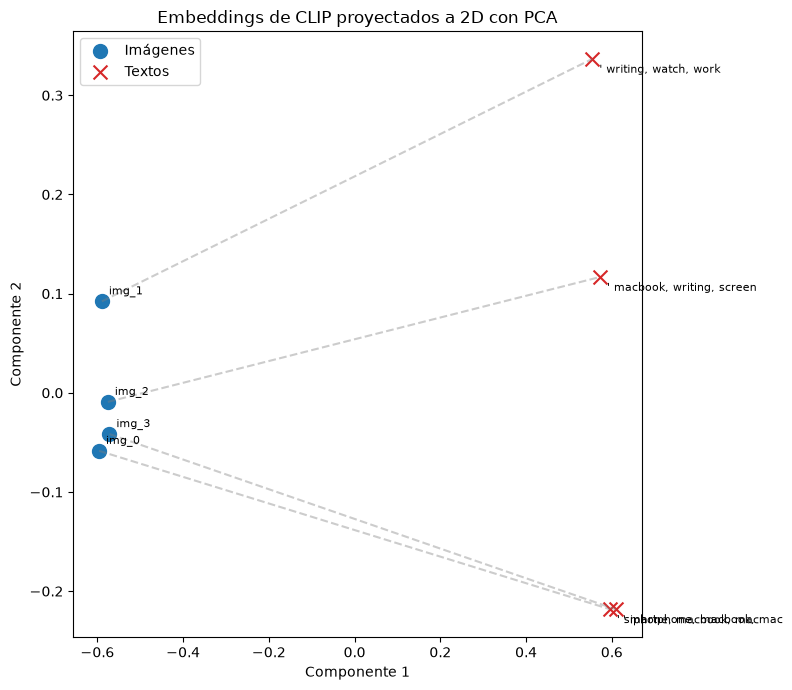

Varianza explicada por las 2 componentes: 89.71%


In [42]:
import numpy as np
from sklearn.decomposition import PCA

# Concatenamos ambos conjuntos de embeddings para proyectarlos en el MISMO espacio 2D
all_embeds = np.vstack([image_embeds_np, text_embeds_np])

pca = PCA(n_components=2, random_state=42)
all_2d = pca.fit_transform(all_embeds)

n = len(images)
img_2d = all_2d[:n]
txt_2d = all_2d[n:]

plt.figure(figsize=(8, 7))
plt.scatter(img_2d[:, 0], img_2d[:, 1], c="tab:blue", label="Imágenes", s=100)
plt.scatter(txt_2d[:, 0], txt_2d[:, 1], c="tab:red", marker="x", label="Textos", s=100)

for i in range(n):
    plt.annotate(f"img_{i}", (img_2d[i, 0], img_2d[i, 1]), fontsize=8, xytext=(5, 5), textcoords="offset points")
    plt.annotate(text_prompts[i], (txt_2d[i, 0], txt_2d[i, 1]), fontsize=8, xytext=(5, -10), textcoords="offset points")
    # Línea que une cada imagen con su descripción real
    plt.plot([img_2d[i, 0], txt_2d[i, 0]], [img_2d[i, 1], txt_2d[i, 1]], "gray", alpha=0.4, linestyle="--")

plt.title("Embeddings de CLIP proyectados a 2D con PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

> **Nota:** con pocos puntos (como en este ejemplo) PCA suele ser más estable que t-SNE o UMAP, que están pensados para datasets más grandes. Si quieres experimentar con t-SNE, descomenta la celda siguiente (requiere ajustar `perplexity` a un valor menor que el número de muestras).

In [ ]:
# from sklearn.manifold import TSNE
#
# tsne = TSNE(n_components=2, perplexity=3, random_state=42, init="pca")
# all_2d_tsne = tsne.fit_transform(all_embeds)
#
# img_2d_tsne = all_2d_tsne[:n]
# txt_2d_tsne = all_2d_tsne[n:]
#
# plt.figure(figsize=(8, 7))
# plt.scatter(img_2d_tsne[:, 0], img_2d_tsne[:, 1], c="tab:blue", label="Imágenes", s=100)
# plt.scatter(txt_2d_tsne[:, 0], txt_2d_tsne[:, 1], c="tab:red", marker="x", label="Textos", s=100)
# for i in range(n):
#     plt.annotate(f"img_{i}", (img_2d_tsne[i, 0], img_2d_tsne[i, 1]))
#     plt.annotate(text_prompts[i], (txt_2d_tsne[i, 0], txt_2d_tsne[i, 1]))
# plt.title("Embeddings de CLIP proyectados a 2D con t-SNE")
# plt.legend()
# plt.show()

## 4. Verificar emparejamientos con cosine similarity

Calculamos la matriz de similitud coseno entre todos los embeddings de imagen y de texto. Como ya están normalizados, la similitud coseno es simplemente el producto punto. Con esta matriz podemos hacer:

- **Búsqueda texto → imagen**: dado un texto, encontrar la imagen más parecida.
- **Búsqueda imagen → texto**: dada una imagen, encontrar el texto más parecido.

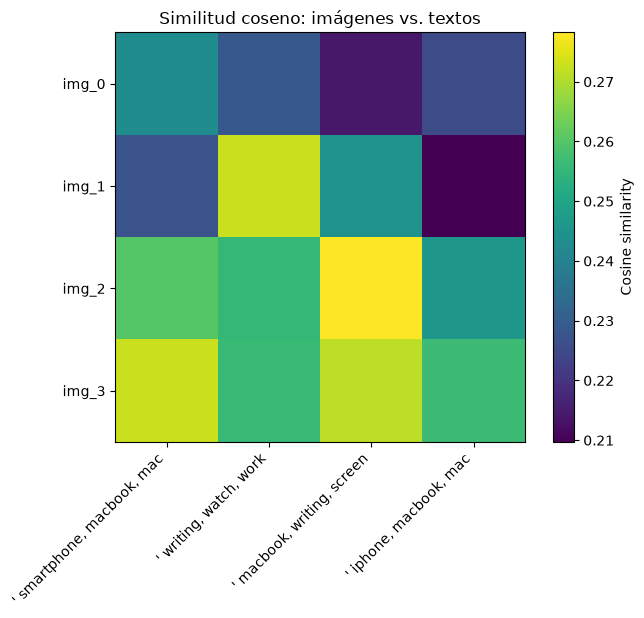

Matriz de similitud (imagen x texto):
[[0.243 0.229 0.214 0.225]
 [0.227 0.273 0.245 0.21 ]
 [0.26  0.255 0.278 0.246]
 [0.273 0.256 0.271 0.257]]


In [43]:
# Matriz de similitud: filas = imágenes, columnas = textos
similarity = image_embeds_np @ text_embeds_np.T  # (n_imagenes, n_textos)

plt.figure(figsize=(7, 6))
plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(text_prompts)), text_prompts, rotation=45, ha="right")
plt.yticks(range(len(images)), [f"img_{i}" for i in range(len(images))])
plt.title("Similitud coseno: imágenes vs. textos")
plt.tight_layout()
plt.show()

print("Matriz de similitud (imagen x texto):")
print(np.round(similarity, 3))

In [44]:
# --- Búsqueda texto -> imagen ---
print("=== Búsqueda texto → imagen ===")
for j, txt in enumerate(text_prompts):
    best_img_idx = similarity[:, j].argmax()
    print(f"Texto: '{txt}'  ->  Imagen más parecida: img_{best_img_idx} "
          f"(similitud={similarity[best_img_idx, j]:.3f})  [correcto: {best_img_idx == j}]")

print("\n=== Búsqueda imagen → texto ===")
for i in range(len(images)):
    best_txt_idx = similarity[i, :].argmax()
    print(f"Imagen: img_{i}  ->  Texto más parecido: '{text_prompts[best_txt_idx]}' "
          f"(similitud={similarity[i, best_txt_idx]:.3f})  [correcto: {best_txt_idx == i}]")

accuracy_t2i = np.mean([similarity[:, j].argmax() == j for j in range(len(text_prompts))])
accuracy_i2t = np.mean([similarity[i, :].argmax() == i for i in range(len(images))])
print(f"\nExactitud texto→imagen: {accuracy_t2i:.0%}")
print(f"Exactitud imagen→texto: {accuracy_i2t:.0%}")

=== Búsqueda texto → imagen ===
Texto: '' smartphone, macbook, mac'  ->  Imagen más parecida: img_3 (similitud=0.273)  [correcto: False]
Texto: '' writing, watch, work'  ->  Imagen más parecida: img_1 (similitud=0.273)  [correcto: True]
Texto: '' macbook, writing, screen'  ->  Imagen más parecida: img_2 (similitud=0.278)  [correcto: True]
Texto: '' iphone, macbook, mac'  ->  Imagen más parecida: img_3 (similitud=0.257)  [correcto: True]

=== Búsqueda imagen → texto ===
Imagen: img_0  ->  Texto más parecido: '' smartphone, macbook, mac' (similitud=0.243)  [correcto: True]
Imagen: img_1  ->  Texto más parecido: '' writing, watch, work' (similitud=0.273)  [correcto: True]
Imagen: img_2  ->  Texto más parecido: '' macbook, writing, screen' (similitud=0.278)  [correcto: True]
Imagen: img_3  ->  Texto más parecido: '' smartphone, macbook, mac' (similitud=0.273)  [correcto: False]

Exactitud texto→imagen: 75%
Exactitud imagen→texto: 75%


### 4.1 Visualizar el mejor emparejamiento

Mostramos, para un texto de ejemplo, la imagen que CLIP considera más similar.

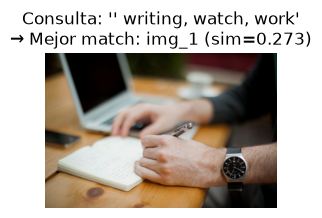

In [53]:
query_text = text_prompts[1]  # cambia el índice para probar otras consultas
query_idx = text_prompts.index(query_text)
best_img_idx = similarity[:, query_idx].argmax()

plt.figure(figsize=(3, 3))
plt.imshow(images[best_img_idx])
plt.title(f"Consulta: '{query_text}'\n→ Mejor match: img_{best_img_idx} "
          f"(sim={similarity[best_img_idx, query_idx]:.3f})")
plt.axis("off")
plt.show()

## Conclusiones

- CLIP mapea imágenes y textos a **vectores de la misma dimensión** (512 en `clip-vit-base-patch32`), lo que permite compararlos directamente.
- Al proyectar los embeddings a 2D con PCA, las imágenes y sus descripciones textuales correctas tienden a quedar **cercanas entre sí** en el plano.
- La **cosine similarity** entre embeddings de imagen y texto permite hacer búsqueda cruzada (texto→imagen e imagen→texto) sin necesidad de entrenar un modelo adicional, lo cual es la base de aplicaciones como búsqueda semántica de imágenes, generación de descripciones automáticas y sistemas de recuperación multimodal.